# Pokémon Type Classification - Task 3: Transfer Learning

**Model:** ResNet-50 (ImageNet pretrained)
**Metric:** Macro-averaged F1
**Strategy:** Two-phase training - head only → partial backbone unfreeze
**Dataset:** 1 194 labelled images, 9 Pokémon types, real-world backgrounds

In [98]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.8.0+cu126
CUDA available: True


In [99]:
SEED = 42

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark    = True


In [100]:
# Hyperparameters
IMG_SIZE     = 224
BATCH_SIZE   = 32
VAL_RATIO    = 0.20
NUM_WORKERS  = 0

# Phase 1 - head only
LR_HEAD      = 1e-3
WD_HEAD      = 1e-4
HEAD_EPOCHS  = 10
HEAD_PATIENCE = 5

# Phase 2 - backbone + head
LR_FINE      = 2e-4
WD_FINE      = 5e-4
FINE_EPOCHS  = 25
FINE_PATIENCE = 6

LABEL_SMOOTHING = 0.0
MIXUP_ALPHA     = 0.3

RUN_NAME = "transfer_resnet50_img224_v5"

In [101]:
# Paths
if "notebooks" in os.getcwd():
    BASE_DIR = os.path.join(os.path.dirname(os.getcwd()), "data", "task3")
else:
    BASE_DIR = os.path.join("data", "task3")

RUN_DIR = os.path.join(os.path.dirname(os.path.dirname(BASE_DIR)), "submissions", RUN_NAME)

TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")
LABELS_CSV = os.path.join(BASE_DIR, "train_labels.csv")

os.makedirs(RUN_DIR, exist_ok=True)

CKPT_PATH       = os.path.join(RUN_DIR, "best_model.pth")
SUBMISSION_PATH = os.path.join(RUN_DIR, "submission.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"BASE_DIR  : {BASE_DIR}")
print(f"TRAIN_DIR : {TRAIN_DIR}  exists={os.path.isdir(TRAIN_DIR)}")
print(f"TEST_DIR  : {TEST_DIR}   exists={os.path.isdir(TEST_DIR)}")
print(f"LABELS    : {LABELS_CSV} exists={os.path.isfile(LABELS_CSV)}")
print(f"RUN_DIR   : {RUN_DIR}")
print(f"DEVICE    : {DEVICE}")

BASE_DIR  : c:\Projects\DeepLearning\Assignment1\data\task3
TRAIN_DIR : c:\Projects\DeepLearning\Assignment1\data\task3\train  exists=True
TEST_DIR  : c:\Projects\DeepLearning\Assignment1\data\task3\test   exists=True
LABELS    : c:\Projects\DeepLearning\Assignment1\data\task3\train_labels.csv exists=True
RUN_DIR   : c:\Projects\DeepLearning\Assignment1\submissions\transfer_resnet50_img224_v5
DEVICE    : cuda


## 1 - Data Exploration


In [102]:
df = pd.read_csv(LABELS_CSV)
print("Total samples :", len(df))
print("Columns       :", df.columns.tolist())
print("Classes       :", sorted(df["label"].unique()))
print("Num classes   :", df["label"].nunique())
df.head()


Total samples : 1194
Columns       : ['Id', 'label']
Classes       : ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']
Num classes   : 9


,Id,label
0,6702e55d-8172-492a-8f87-a3da277b53a7,Water
1,f93ea8ca-a4ad-475a-9c2a-12baaace2992,Water
2,be649239-3880-4369-846d-8030b182d18e,Water
3,cc812e42-37e1-40c5-a49f-60eafd030943,Water
4,e2af2db9-2978-4274-824a-13cb62b8c08c,Water


          count   pct
label                
Water       252  21.1
Normal      222  18.6
Grass       159  13.3
Bug         150  12.6
Fire        114   9.5
Rock         99   8.3
Ground       72   6.0
Poison       66   5.5
Fighting     60   5.0


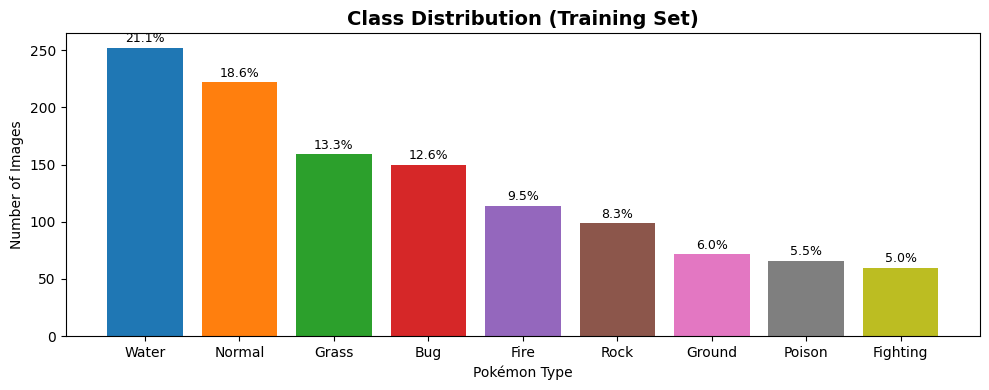


Max/min imbalance ratio: 4.2x


In [103]:
counts = df["label"].value_counts().sort_values(ascending=False)
pct    = (counts / counts.sum() * 100).round(1)

dist_df = pd.DataFrame({"count": counts, "pct": pct})
print(dist_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(counts.index, counts.values, color=plt.cm.tab10.colors)
ax.set_title("Class Distribution (Training Set)", fontsize=14, fontweight="bold")
ax.set_xlabel("Pokémon Type")
ax.set_ylabel("Number of Images")
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2, f"{p}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "class_distribution.png"), dpi=150)
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"\nMax/min imbalance ratio: {imbalance_ratio:.1f}x")

## 2 - Train / Validation Split


In [104]:
le = LabelEncoder()
df["label_idx"] = le.fit_transform(df["label"])
NUM_CLASSES = len(le.classes_)
print("Classes:", le.classes_.tolist())

train_df, val_df = train_test_split(
    df,
    test_size=VAL_RATIO,
    stratify=df["label_idx"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} samples | Val: {len(val_df)} samples")
print("Train class counts:", np.bincount(train_df["label_idx"]).tolist())
print("Val class counts:", np.bincount(val_df["label_idx"]).tolist())


Classes: ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']

Train: 955 samples | Val: 239 samples
Train class counts: [120, 48, 91, 127, 58, 178, 53, 79, 201]
Val class counts: [30, 12, 23, 32, 14, 44, 13, 20, 51]


## 3 - Dataset & Transforms


In [105]:
class PokemonDataset(Dataset):
    """Labelled Pokémon image dataset."""

    def __init__(self, dataframe: pd.DataFrame, img_dir: str,
                 transform=None) -> None:
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row["Id"]) + ".png")
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(row["label_idx"])


class PokemonTestDataset(Dataset):
    """Unlabelled test dataset - returns (image, image_id)."""

    def __init__(self, test_dir: str, transform=None) -> None:
        self.files     = sorted(os.listdir(test_dir))
        self.test_dir  = test_dir
        self.transform = transform

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int):
        fname    = self.files[idx]
        img_id   = os.path.splitext(fname)[0]
        image    = Image.open(os.path.join(self.test_dir, fname)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_id


In [106]:
# ImageNet stats
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

# Phase 1 - light augmentation (backbone is frozen)
head_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

# Phase 2 - heavier augmentation + RandomErasing
finetune_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.35, contrast=0.35,
                           saturation=0.25, hue=0.08),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

# Val / test - no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

In [107]:
train_dataset = PokemonDataset(train_df, TRAIN_DIR, transform=head_transform)
val_dataset   = PokemonDataset(val_df,   TRAIN_DIR, transform=val_transform)

class_counts = np.bincount(train_df['label_idx'])

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False,
)

print(f'Train: {len(train_dataset)} samples | Val: {len(val_dataset)} samples')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
print(f'Class counts (train): {class_counts.tolist()}')

Train: 955 samples | Val: 239 samples
Train batches: 30 | Val batches: 8
Class counts (train): [120, 48, 91, 127, 58, 178, 53, 79, 201]


## 4 - Model: ResNet-50

We're using ResNet-50 pretrained on ImageNet. The skip connections help with gradient flow, and the pretrained weights already know how to extract useful low-level features (edges, textures, etc.) which should transfer well to our task.

The classification head is kept simple — just `Dropout → Linear` — since we only have ~950 training samples and don't want to overfit.

In [108]:
def build_model(num_classes):
    weights = ResNet50_Weights.DEFAULT
    model   = resnet50(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model


def freeze_backbone(model):
    for name, param in model.named_parameters():
        param.requires_grad = ("fc" in name)


def unfreeze_top_blocks(model):
    """Unfreeze layer2, layer3, layer4, and fc."""
    for name, param in model.named_parameters():
        unfreeze = any(tag in name for tag in ["layer2", "layer3", "layer4", "fc"])
        param.requires_grad = unfreeze


def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = build_model(NUM_CLASSES).to(DEVICE)
print("Total params    :", sum(p.numel() for p in model.parameters()))
print("Trainable params:", count_trainable(model), "(all, before freeze)")

Total params    : 23526473
Trainable params: 23526473 (all, before freeze)


## 5 - Loss Function & Evaluation Helper


In [109]:
# Sqrt-dampened inverse frequency weights to handle class imbalance
class_weights = torch.tensor(
    [1.0 / np.sqrt(class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32,
)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)

print('Class weights:')
for cls, w in zip(le.classes_, class_weights.cpu().numpy()):
    print(f'  {cls:<12} {w:.4f}')

Class weights:
  Bug          0.8595
  Fighting     1.3590
  Fire         0.9870
  Grass        0.8355
  Ground       1.2363
  Normal       0.7057
  Poison       1.2933
  Rock         1.0593
  Water        0.6641


In [110]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item() * len(y)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1, all_preds, all_labels

In [111]:
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def run_phase(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    epochs, patience, phase_name, ckpt_path, device, mixup_alpha=0.0,
):
    """Train with early stopping on val macro-F1. Supports Mixup."""
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1      = -1.0
    best_weights = None
    no_improve   = 0

    print(f"\n{'='*60}")
    print(f"{phase_name}  |  trainable params: {count_trainable(model):,}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for X, y in tqdm(train_loader, desc=f"Ep {epoch}/{epochs} [train]",
                          leave=False):
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

            if mixup_alpha > 0:
                X, y_a, y_b, lam = mixup_data(X, y, mixup_alpha)
                optimizer.zero_grad()
                loss = mixup_criterion(criterion, model(X), y_a, y_b, lam)
            else:
                optimizer.zero_grad()
                loss = criterion(model(X), y)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * len(y)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} val_f1={val_f1:.4f}", end="")

        if val_f1 > best_f1:
            best_f1      = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, ckpt_path)
            no_improve = 0
            print("  * best")
        else:
            no_improve += 1
            print(f"  (no improvement {no_improve}/{patience})")
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    print(f"\nBest val macro-F1 ({phase_name}): {best_f1:.4f}")
    return history

## 6 - Phase 1: Head Training (backbone frozen)

We freeze the entire backbone and only train the new classification head. This way the pretrained features stay intact while the head learns to map them to our 9 classes. A few epochs is enough for this to converge.

In [112]:
freeze_backbone(model)
print("Trainable params after freeze:", count_trainable(model))

optimizer_head = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WD_HEAD,
)
scheduler_head = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_head, T_max=HEAD_EPOCHS, eta_min=1e-5,
)

train_dataset.transform = head_transform

CKPT_PHASE1 = os.path.join(RUN_DIR, "best_model_phase1.pth")

history_phase1 = run_phase(
    model, train_loader, val_loader, criterion,
    optimizer_head, scheduler_head,
    epochs=HEAD_EPOCHS, patience=HEAD_PATIENCE,
    phase_name="Phase 1 -- Head only (backbone frozen)",
    ckpt_path=CKPT_PHASE1, device=DEVICE,
    mixup_alpha=0.0,
)

Trainable params after freeze: 18441

Phase 1 -- Head only (backbone frozen)  |  trainable params: 18,441


Ep 1/10 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1 | train_loss=2.2045 val_loss=2.1654 val_f1=0.0877  * best


Ep 2/10 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   2 | train_loss=2.0621 val_loss=2.1592 val_f1=0.0677  (no improvement 1/5)


...

Epoch   8 | train_loss=1.7284 val_loss=2.1570 val_f1=0.1280  (no improvement 1/5)


Ep 9/10 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   9 | train_loss=1.7277 val_loss=2.1667 val_f1=0.1315  * best


Ep 10/10 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch  10 | train_loss=1.7205 val_loss=2.1543 val_f1=0.1302  (no improvement 1/5)

Best val macro-F1 (Phase 1 -- Head only (backbone frozen)): 0.1315


## 7 - Phase 2: Fine-Tuning (top blocks + head)

Now we unfreeze `layer2`, `layer3`, `layer4` and the head so the upper part of the backbone can adapt to Pokémon-specific patterns (shapes, colours, markings). The early layers (`conv1`, `bn1`, `layer1`) stay frozen since they mostly capture generic low-level features.

Learning rate is lower than Phase 1 to avoid messing up the pretrained weights with large updates.

In [113]:
unfreeze_top_blocks(model)
print("Trainable params after unfreeze:", count_trainable(model))

train_dataset.transform = finetune_transform

optimizer_fine = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINE, weight_decay=WD_FINE,
)
scheduler_fine = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fine, T_max=FINE_EPOCHS, eta_min=1e-6,
)

CKPT_PHASE2 = os.path.join(RUN_DIR, "best_model_phase2.pth")

history_phase2 = run_phase(
    model, train_loader, val_loader, criterion,
    optimizer_fine, scheduler_fine,
    epochs=FINE_EPOCHS, patience=FINE_PATIENCE,
    phase_name="Phase 2 -- Fine-tuning (layer2 + layer3 + layer4 + fc)",
    ckpt_path=CKPT_PHASE2, device=DEVICE,
    mixup_alpha=MIXUP_ALPHA,
)

Trainable params after unfreeze: 23301129

Phase 2 -- Fine-tuning (layer2 + layer3 + layer4 + fc)  |  trainable params: 23,301,129


Ep 1/25 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1 | train_loss=2.0373 val_loss=2.1504 val_f1=0.1492  * best


Ep 2/25 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   2 | train_loss=1.8371 val_loss=1.9621 val_f1=0.2913  * best


...

Epoch  18 | train_loss=0.6613 val_loss=1.9104 val_f1=0.3839  (no improvement 4/6)


Ep 19/25 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch  19 | train_loss=0.7268 val_loss=1.8347 val_f1=0.3728  (no improvement 5/6)


Ep 20/25 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch  20 | train_loss=0.7532 val_loss=1.8014 val_f1=0.3806  (no improvement 6/6)
Early stopping at epoch 20.

Best val macro-F1 (Phase 2 -- Fine-tuning (layer2 + layer3 + layer4 + fc)): 0.4132


## 8 - Final Evaluation


In [114]:
import shutil

phase1_best_f1 = max(history_phase1["val_f1"])
phase2_best_f1 = max(history_phase2["val_f1"])

if phase1_best_f1 > phase2_best_f1:
    print(f"Phase 1 ({phase1_best_f1:.4f}) > Phase 2 ({phase2_best_f1:.4f}) -- using Phase 1 checkpoint")
    best_ckpt = CKPT_PHASE1
else:
    print(f"Phase 2 ({phase2_best_f1:.4f}) >= Phase 1 ({phase1_best_f1:.4f}) -- using Phase 2 checkpoint")
    best_ckpt = CKPT_PHASE2

model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
shutil.copy2(best_ckpt, CKPT_PATH)

val_loss, val_f1, all_preds, all_labels = evaluate(
    model, val_loader, criterion, DEVICE
)

print("=" * 60)
print("FINAL RESULTS -- ResNet-50 Transfer Learning")
print("=" * 60)
print(f"Val Loss    : {val_loss:.4f}")
print(f"Val Macro-F1: {val_f1:.4f}")
print()
report = classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    digits=4,
)
print(report)

with open(os.path.join(RUN_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

Phase 2 (0.4132) >= Phase 1 (0.1315) -- using Phase 2 checkpoint
FINAL RESULTS -- ResNet-50 Transfer Learning
Val Loss    : 1.8366
Val Macro-F1: 0.4132

              precision    recall  f1-score   support

         Bug     0.5769    0.5000    0.5357        30
    Fighting     0.1818    0.1667    0.1739        12
        Fire     0.5161    0.6957    0.5926        23
       Grass     0.6875    0.6875    0.6875        32
      Ground     0.3571    0.3571    0.3571        14
      Normal     0.3265    0.3636    0.3441        44
      Poison     0.1667    0.1538    0.1600        13
        Rock     0.2917    0.3500    0.3182        20
       Water     0.6250    0.4902    0.5495        51

    accuracy                         0.4603       239
   macro avg     0.4144    0.4183    0.4132       239
weighted avg     0.4711    0.4603    0.4619       239



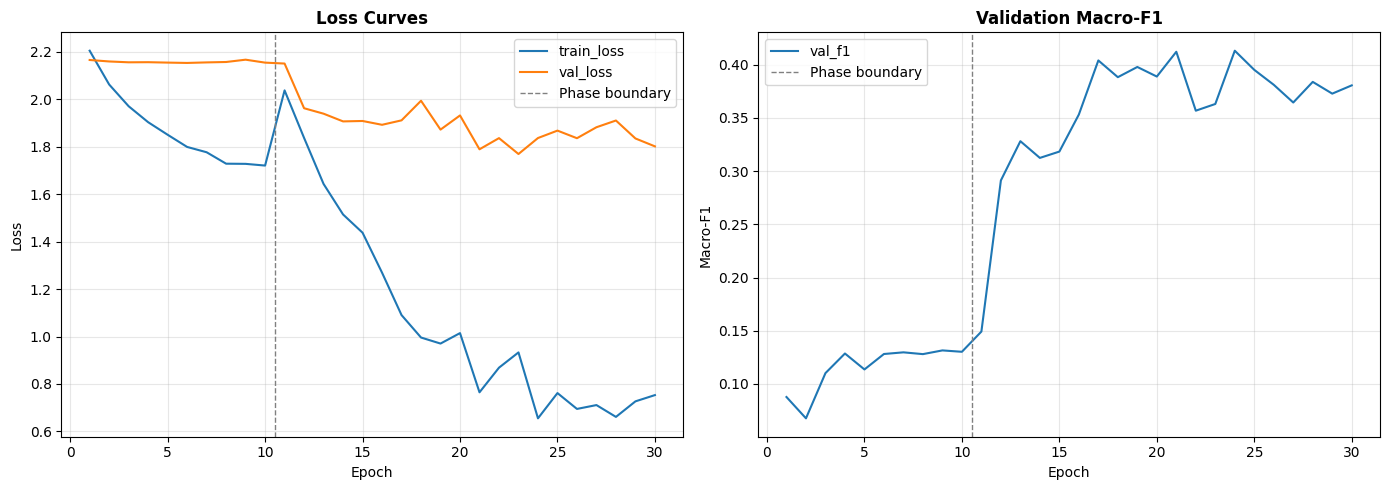

In [115]:
# Training curves
history = {
    "train_loss": history_phase1["train_loss"] + history_phase2["train_loss"],
    "val_loss"  : history_phase1["val_loss"]   + history_phase2["val_loss"],
    "val_f1"    : history_phase1["val_f1"]     + history_phase2["val_f1"],
}
phase1_len = len(history_phase1["val_f1"])
epochs_all = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, ylabel, title in [
    (axes[0], ("train_loss", "val_loss"), "Loss",      "Loss Curves"),
    (axes[1], ("val_f1",),               "Macro-F1",  "Validation Macro-F1"),
]:
    for k in key:
        ax.plot(epochs_all, history[k], label=k)
    ax.axvline(phase1_len + 0.5, color="gray", linestyle="--",
               linewidth=1, label="Phase boundary")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "training_curves.png"), dpi=150)
plt.show()

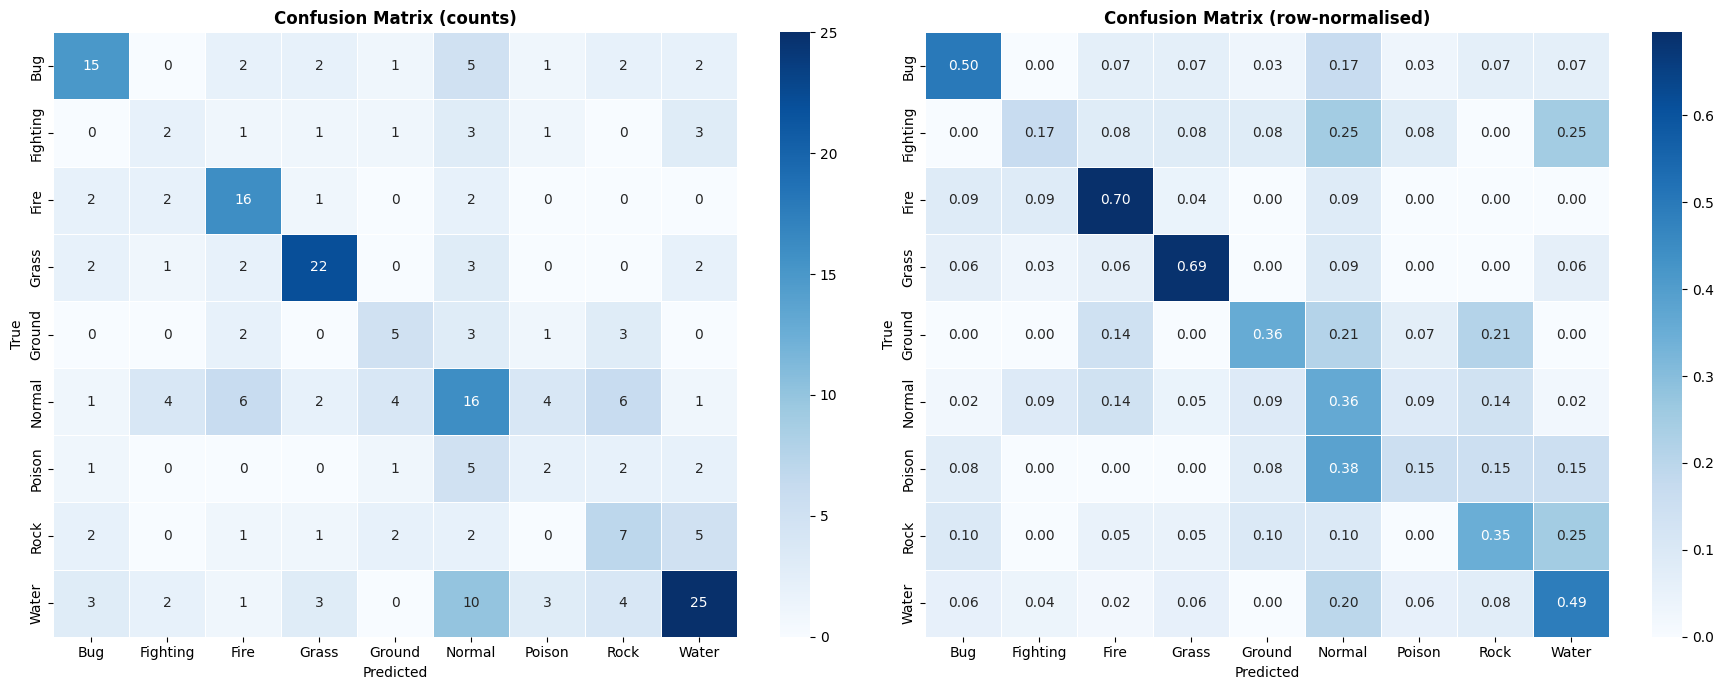

Top confused pairs (true -> predicted, count):
  Water        -> Normal        10
  Normal       -> Fire          6
  Normal       -> Rock          6
  Rock         -> Water         5
  Poison       -> Normal        5


In [116]:
# Confusion matrices
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, fmt, title in [
    (axes[0], cm,      "d",    "Confusion Matrix (counts)"),
    (axes[1], cm_norm, ".2f",  "Confusion Matrix (row-normalised)"),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=le.classes_, yticklabels=le.classes_,
        ax=ax, linewidths=0.5,
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

# Most confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
flat_idx = cm_no_diag.flatten().argsort()[::-1][:5]
print("Top confused pairs (true -> predicted, count):")
for idx in flat_idx:
    r, c = divmod(idx, NUM_CLASSES)
    if cm_no_diag[r, c] > 0:
        print(f"  {le.classes_[r]:<12} -> {le.classes_[c]:<12}  {cm_no_diag[r, c]}")

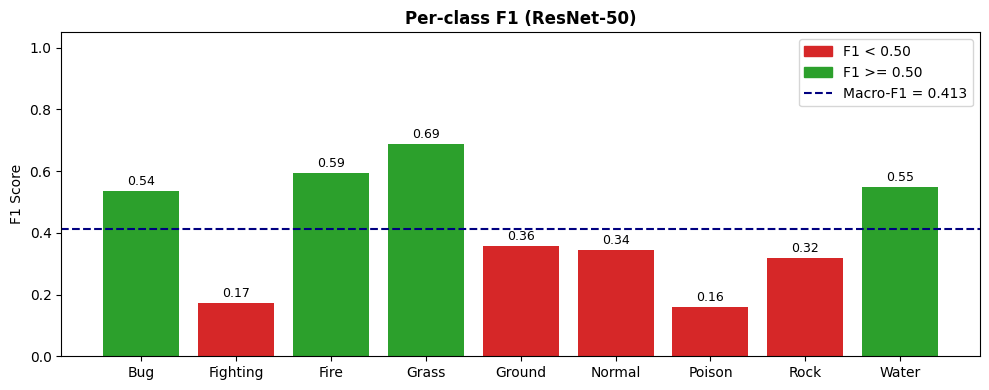

In [117]:
# Per-class F1
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#d62728" if f < 0.5 else "#2ca02c" for f in per_class_f1]
bars = ax.bar(le.classes_, per_class_f1, color=colors)
ax.axhline(val_f1, color="navy", linestyle="--", linewidth=1.5,
           label=f"Macro-F1 = {val_f1:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1 (ResNet-50)", fontweight="bold")
for bar, v in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01, f"{v:.2f}",
            ha="center", va="bottom", fontsize=9)
red_patch   = mpatches.Patch(color="#d62728", label="F1 < 0.50")
green_patch = mpatches.Patch(color="#2ca02c", label="F1 >= 0.50")
ax.legend(handles=[red_patch, green_patch,
                   plt.Line2D([0], [0], color="navy", linestyle="--",
                              label=f"Macro-F1 = {val_f1:.3f}")])
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "per_class_f1.png"), dpi=150)
plt.show()

## 9 - Test Inference & Submission


In [118]:
# Test-Time Augmentation — average predictions over N augmented views
TTA_N = 5

tta_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

test_dataset = PokemonTestDataset(TEST_DIR, transform=val_transform)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False,
)

model.eval()
softmax_fn = nn.Softmax(dim=1)

with torch.no_grad():
    # Base pass (also collects image IDs)
    test_ids = []
    base_probs = []
    for X, img_ids in tqdm(test_loader, desc="TTA pass 1/base"):
        base_probs.append(softmax_fn(model(X.to(DEVICE))).cpu())
        test_ids.extend(img_ids)
    all_probs = [torch.cat(base_probs)]

    # Augmented passes
    for t in range(1, TTA_N):
        tta_ds = PokemonTestDataset(TEST_DIR, transform=tta_transform)
        tta_loader = DataLoader(
            tta_ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=False,
        )
        run_probs = []
        for X, _ in tqdm(tta_loader, desc=f"TTA pass {t+1}/{TTA_N}", leave=False):
            run_probs.append(softmax_fn(model(X.to(DEVICE))).cpu())
        all_probs.append(torch.cat(run_probs))

avg_probs  = torch.stack(all_probs).mean(0)
test_preds = avg_probs.argmax(dim=1).numpy()

pred_labels = le.inverse_transform(test_preds)
submission  = pd.DataFrame({"Id": test_ids, "label": pred_labels})
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission saved -> {SUBMISSION_PATH}")
print(f"Rows: {len(submission)}")
print("\nPrediction distribution:")
print(submission["label"].value_counts().to_string())
submission.head(10)

TTA pass 1/base:   0%|          | 0/10 [00:00<?, ?it/s]

TTA pass 2/5:   0%|          | 0/10 [00:00<?, ?it/s]

TTA pass 3/5:   0%|          | 0/10 [00:00<?, ?it/s]

TTA pass 4/5:   0%|          | 0/10 [00:00<?, ?it/s]

TTA pass 5/5:   0%|          | 0/10 [00:00<?, ?it/s]

Submission saved -> c:\Projects\DeepLearning\Assignment1\submissions\transfer_resnet50_img224_v5\submission.csv
Rows: 300

Prediction distribution:
label
Normal      73
Water       62
Grass       52
Bug         35
Rock        23
Fire        23
Poison      14
Ground      12
Fighting     6


,Id,label
0,0020aec0-f6b6-4672-b60a-bcfe05d16431,Normal
1,005c1fab-6223-40ed-9b27-e64b519a4412,Bug
2,01470d4e-218d-4ba9-9a40-c3dc3f7e85c8,Fighting
3,0180f914-baae-4b13-ae34-5e288e861de4,Poison
4,0268167e-10e8-46a6-9809-3cb58520404e,Water
5,03af91cb-17c8-4b95-8ea0-8e58b9d31e36,Bug
6,03efe05e-c6ba-4bbc-9462-ad467a3d7408,Normal
7,046e952b-fc8a-4e25-8b2c-8359df12edbb,Normal
8,04ce5005-7a7c-4379-a198-7985c3f6905c,Rock
9,04e52b48-797f-41cf-9f8d-852b4a10d2f3,Water


In [119]:
# Save run summary
summary = (
    f"Task 3 - Transfer Learning ResNet-50\n"
    f"Val Loss     : {val_loss:.4f}\n"
    f"Val Macro-F1 : {val_f1:.4f}\n"
    f"Best ckpt    : {CKPT_PATH}\n"
    f"Submission   : {SUBMISSION_PATH}\n"
)
config_txt = (
    f"Model        : ResNet-50\n"
    f"Image size   : {IMG_SIZE}\n"
    f"Batch size   : {BATCH_SIZE}\n"
    f"Val ratio    : {VAL_RATIO}\n"
    f"Head LR      : {LR_HEAD}\n"
    f"Fine-tune LR : {LR_FINE}\n"
    f"WD (head)    : {WD_HEAD}\n"
    f"WD (fine)    : {WD_FINE}\n"
    f"Label smooth : {LABEL_SMOOTHING}\n"
    f"Head epochs  : {HEAD_EPOCHS}\n"
    f"Fine epochs  : {FINE_EPOCHS}\n"
    f"Frozen until : layer1 (unfreeze layer2, layer3, layer4, fc)\n"
    f"Augmentation : RandomResizedCrop + Flips + ColorJitter + Rotation + Affine + RandomErasing\n"
    f"Balancing    : class-weighted loss (sqrt-dampened)\n"
    f"Classes      : {le.classes_.tolist()}\n"
    f"Train samples: {len(train_df)}\n"
    f"Val samples  : {len(val_df)}\n"
)
with open(os.path.join(RUN_DIR, "summary.txt"), "w") as f:
    f.write(summary)
with open(os.path.join(RUN_DIR, "config.txt"), "w") as f:
    f.write(config_txt)

print(summary)
print(config_txt)

Task 3 - Transfer Learning ResNet-50
Val Loss     : 1.8366
Val Macro-F1 : 0.4132
Best ckpt    : c:\Projects\DeepLearning\Assignment1\submissions\transfer_resnet50_img224_v5\best_model.pth
Submission   : c:\Projects\DeepLearning\Assignment1\submissions\transfer_resnet50_img224_v5\submission.csv

Model        : ResNet-50
Image size   : 224
Batch size   : 32
Val ratio    : 0.2
Head LR      : 0.001
Fine-tune LR : 0.0002
WD (head)    : 0.0001
WD (fine)    : 0.0005
Label smooth : 0.0
Head epochs  : 10
Fine epochs  : 25
Frozen until : layer1 (unfreeze layer2, layer3, layer4, fc)
Augmentation : RandomResizedCrop + Flips + ColorJitter + Rotation + Affine + RandomErasing
Balancing    : class-weighted loss (sqrt-dampened)
Classes      : ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']
Train samples: 955
Val samples  : 239

